# **Import Dependencies**

In [ ]:
!pip install google-play-scraper pandas

In [ ]:
!pip install wordcloud

In [ ]:
!pip install vaderSentiment

In [ ]:
!pip install pipreqs

# **Import Library**

In [ ]:
# Install library eksternal (jalankan di awal)
!pip install google-play-scraper
!pip install sastrawi

# ==============================
# 📚 Library untuk Data & Komputasi
# ==============================
import pandas as pd
import numpy as np
import csv
import time
import re
import datetime as dt
from io import StringIO
import requests
import string
# ==============================
# 📊 Visualisasi
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# ==============================
# 🧠 Machine Learning & NLP Tools
# ==============================
from sklearn.metrics import accuracy_score
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('punkt')
nltk.download('stopwords')

# ==============================
# 🇮🇩 NLP Bahasa Indonesia
# ==============================
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ==============================
# 🏬 Google Play Scraper
# ==============================
from google_play_scraper import app, reviews, Sort, reviews_all

# ==============================
# 🔧 Pengaturan
# ==============================
pd.options.mode.chained_assignment = None
seed = 0
np.random.seed(seed)


  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl.metadata (909 bytes)
Using cached Sastrawi-1.0.1-py2.py3-none-any.whl (209 kB)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **Scrapping menggunakan google play scraper**

In [ ]:
app_id = 'com.mobile.legends'
total_reviews = 70000
batch_size = 5000
review_df = []


while len(review_df) < total_reviews:
    try:
        result, _ = reviews(
            app_id,
            lang='id',
            country='id',
            sort=Sort.MOST_RELEVANT,
            count=batch_size,
            filter_score_with=5,
            continuation_token=None if not review_df else token
        )
        review_df.extend(result)
        token = _
        print(f"Jumlah review terkumpul: {len(review_df)}")
        time.sleep(1)
    except Exception as e:
        print("Terjadi error:", e)
        break

Jumlah review terkumpul: 5000
Jumlah review terkumpul: 10000
Jumlah review terkumpul: 15000
Jumlah review terkumpul: 20000
Jumlah review terkumpul: 25000
Jumlah review terkumpul: 30000
Jumlah review terkumpul: 35000
Jumlah review terkumpul: 40000
Jumlah review terkumpul: 45000
Jumlah review terkumpul: 50000
Jumlah review terkumpul: 55000
Jumlah review terkumpul: 60000
Jumlah review terkumpul: 65000
Jumlah review terkumpul: 70000


In [ ]:
df = pd.DataFrame(review_df)

In [ ]:
df = df[['at','userName', 'score', 'content']]
df.to_csv('df_ml.csv', index=False)

print("Total review yang disimpan:", len(df))

Total review yang disimpan: 70000


# **Membaca Dataset**

In [ ]:
df = pd.read_csv('df_ml.csv')

In [ ]:
df.head()

,at,userName,score,content
0,2022-01-12 15:22:08,Pengguna Google,5,Di bilang bagus...tapi kurang. Di bilang jelek...
1,2020-05-21 15:33:13,Pengguna Google,5,Setelah update terbaru ini sinyal makin buruk....
2,2021-01-15 07:18:53,Pengguna Google,5,"Game nya udah bagus mulai dari control, grafik..."
3,2018-12-27 14:32:51,Pengguna Google,5,Keren Gamenya Mantap! Tapi kadang kadang loadi...
4,2024-06-28 03:46:39,Pengguna Google,5,"Performa game akhir2 ini cukup bagus, game nya..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   at        70000 non-null  object
 1   userName  70000 non-null  object
 2   score     70000 non-null  int64 
 3   content   70000 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


# **Pre-Processing Dataset**

## **Pembersihan Data**

In [ ]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = df.dropna()

In [ ]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   at        70000 non-null  object
 1   userName  70000 non-null  object
 2   score     70000 non-null  int64 
 3   content   70000 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


In [ ]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

## **Casefolding**

In [ ]:
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

## **Tokenisasi**

In [ ]:
def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

## **Pembersihan Stopwords**

In [ ]:
def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

## **Stemming**

In [ ]:
def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

## **To Sentence**

In [ ]:

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

## **Normalisasi**

In [ ]:
slangwords = {'gak': 'tidak', 'ga': 'tidak', 'kaga': 'tidak', 'gk': 'tidak', 'gks': 'tidak', 'tdk': 'tidak', 'g': 'tidak',
    'udah': 'sudah', 'uda': 'sudah', 'dah': 'sudah', 'dlu': 'dulu',
    'kalo': 'kalau', 'kl': 'kalau', 'pas': 'saat', 'bae': 'saja',
    'kpn': 'kapan', 'kapan2': 'kapan-kapan',
    'gmn': 'bagaimana', 'gmna': 'bagaimana', 'gimana': 'bagaimana',
    'bs': 'bisa', 'bisa2': 'bisa-bisa', 'bsa': 'bisa',
    'knp': 'kenapa', 'knpa': 'kenapa', 'napa': 'kenapa', 'napaa': 'kenapa',
    'jd': 'jadi', 'jdi': 'jadi', 'jadinya': 'jadi',
    'cm': 'cuma', 'cuman': 'cuma', 'cmn': 'cuma',
    'hrs': 'harus', 'hrus': 'harus', 'mst': 'harus',
    'lgsg': 'langsung', 'lgs': 'langsung', 'langsung2': 'langsung',
    'lu': 'kamu', 'lo': 'kamu', 'km': 'kamu',
    'gue': 'saya', 'gua': 'saya', 'gw': 'saya', 'ane': 'saya', 'aku': 'saya', 'ku': 'saya',
    'ni': 'ini', 'nih': 'ini', 'tuh': 'itu', 'tu': 'itu',
    'yg': 'yang', 'plis': 'mohon', 'tolong': 'mohon',
    'makasih': 'terima kasih', 'trims': 'terima kasih', 'thx': 'terima kasih',
    'hadehh': 'aduh', 'hadehhh': 'aduh', 'anjir': 'aduh', 'anjing': 'aduh', 'anying': 'aduh', 'astaga': 'aduh',
    'wtf': 'aduh', 'wth': 'aduh', 'sial': 'aduh', 'sialan': 'aduh', 'damn': 'aduh', 'dammit': 'aduh',
    'bgst': 'aduh', 'bgsd': 'aduh', 'fck': 'aduh', 'fuck': 'aduh', 'anj': 'aduh',
    'pepek': 'buruk', 'ampas': 'buruk', 'burik': 'buruk', 'bosok': 'buruk', 'cacad': 'buruk',
    'jelek': 'buruk', 'jlek': 'buruk', 'jele': 'buruk', 'sucks': 'buruk', 'suck': 'buruk', 'payah': 'buruk', 'pyh': 'buruk',
    'gajelas': 'tidak jelas', 'gj': 'tidak jelas',
    'kocak': 'lucu', 'lol': 'lucu', 'lmao': 'lucu', 'rofl': 'lucu',
    'haha': 'lucu', 'hahaha': 'lucu', 'wkwk': 'lucu', 'wkwkwk': 'lucu',
    'tolol': 'bodoh', 'bego': 'bodoh',
    'ngeselin': 'menjengkelkan', 'kesel': 'jengkel', 'sebel': 'jengkel',
    'males': 'malas', 'mls': 'malas', 'bikin': 'membuat',
    'parah': 'sangat', 'banget': 'sangat', 'bgt': 'sangat', 'banget""': 'sangat',
    'mulu': 'terus', 'trus': 'terus', 'terus': 'terus',
    'tiba2': 'tiba-tiba', 'tb': 'tiba-tiba', 'tiba""': 'tiba-tiba', 'tb""': 'tiba-tiba',
    'sampe': 'sampai', 'smpe': 'sampai', 'samsek': 'sama sekali', 'sampe2': 'sampai',
    'bner': 'benar', 'bener': 'benar', 'bner""': 'benar',
    'benerin': 'perbaiki', 'fix': 'perbaiki',
    'mantap': 'bagus', 'oke': 'bagus', 'okelah': 'bagus', 'bagu': 'bagus',
    'keren': 'bagus', 'kren': 'bagus', 'top': 'bagus', 'topp': 'bagus',
    'gg': 'bagus', 'ggez': 'bagus', 'wp': 'bagus',
    'asik': 'seru', 'seru': 'seru',
    'enak': 'nyaman', 'nyaman': 'nyaman', 'smooth': 'lancar', 'lancar': 'lancar',
    'rame': 'ramai', 'pantes': 'pantas',
    'ngeleg': 'lag', 'ngelag': 'lag', 'ngebug': 'bug', 'ngefreeze': 'freeze',
    'ngefrist': 'freeze', 'ngetroll': 'troll', 'ngefeed': 'feed',
    'mabar': 'main bareng', 'solo': 'main sendiri',
    'bot': 'pemula', 'noob': 'pemula', 'nub': 'pemula', 'newbie': 'pemula',
    'pro': 'jago', 'jago': 'jago', 'op': 'overpowered',
    'mm': 'marksman', 'hyper': 'hypercarry', 'lane': 'jalur', 'jungler': 'jungler',
    'roam': 'roamer', 'roaming': 'roamer', 'exp': 'experience lane', 'goldlane': 'gold lane',
    'mid': 'mid lane', 'midlaner': 'mid laner', 'tank': 'tank', 'supp': 'support', 'support': 'support',
    'carry': 'carry', 'core': 'core', 'gank': 'gank', 'ganking': 'gank',
    'ult': 'ultimate', 'ulti': 'ultimate', 'skill': 'skill', 'skil': 'skill',
    'item': 'item', 'build': 'build', 'nerf': 'nerf', 'buff': 'buff',
    'meta': 'meta', 'offmeta': 'off meta', 'rank': 'rank', 'ranked': 'rank',
    'classic': 'classic', 'brawl': 'brawl', 'mvp': 'mvp', 'mvpnya': 'mvp',
    'push': 'push', 'pushing': 'push', 'turret': 'turret', 'tower': 'turret',
    'minion': 'minion', 'creep': 'minion', 'lord': 'lord', 'turtle': 'turtle',
    'draft': 'draft pick', 'gacha': 'gacha', 'darksistem': 'sistem curang', 'drak': 'sistem curang',
    'lose': 'kalah', 'win': 'menang', 'ws': 'win streak', 'ls': 'lose streak',
    'afk': 'afk', 'dc': 'disconnect', 'dced': 'disconnect',
    'ping': 'ping', 'pinh': 'ping', 'fps': 'fps', 'frame': 'fps',
    'crash': 'crash', 'crashing': 'crash', 'error': 'error', 'eror': 'error',
    'unfair': 'tidak adil', 'gaadil': 'tidak adil', 'cheat': 'curang', 'cheater': 'curang',
    'toxic': 'toxic', 'tox': 'toxic', 'report': 'lapor', 'rpt': 'lapor',
    'ban': 'ban', 'banned': 'ban',
    'woi': 'hai', 'oi': 'hai', 'bro': 'teman',
    'cok': 'kok', 'cokk': 'kok',
    'pokoknya': 'intinya', 'kek': 'seperti', 'kaya': 'seperti', 'kayak': 'seperti',
    'emang': 'memang', 'rmang': 'memang', 'bkn': 'bukan',
    'karna': 'karena', 'krn': 'karena', 'soalnya': 'karena',
    'ntar': 'nanti', 'blm': 'belum', 'lg': 'lagi', 'lgi': 'lagi',
    'skrg': 'sekarang', 'skrng': 'sekarang', 'stlh': 'setelah',
    'masa': 'masa', 'masaa': 'masa',
    'gila': 'gila', 'gilaa': 'gila', 'crazy': 'gila',
    'stress': 'stres', 'stres': 'stres', 'stresful': 'stres',
    'gagal': 'gagal', 'fail': 'gagal',
    'org': 'orang', 'orng': 'orang', 'temen': 'teman', 'tmn': 'teman',
    'main': 'main', 'maen': 'main', 'pake': 'pakai', 'pke': 'pakai',
    'hrsnya': 'seharusnya', 'hrusnya': 'seharusnya',
    'kamera': 'kamera', 'cam': 'kamera', 'grafik': 'grafik', 'graphic': 'grafik',
    'event': 'event', 'evnt': 'event', 'skin': 'skin', 'skn': 'skin',
    'download': 'unduh', 'update': 'perbarui', 'lama""': 'lama', 'patah""': 'patah'}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

## **Penerapan Setelah Preprocessing**

In [ ]:
import nltk
nltk.download('punkt_tab')
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
clean_df

,at,userName,score,content,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,2022-01-12 15:22:08,Pengguna Google,5,Di bilang bagus...tapi kurang. Di bilang jelek...,Di bilang bagustapi kurang Di bilang jelek tap...,di bilang bagustapi kurang di bilang jelek tap...,di bilang bagustapi kurang di bilang buruk tap...,"[di, bilang, bagustapi, kurang, di, bilang, bu...","[bilang, bagustapi, bilang, buruk, bagus, upda...",bilang bagustapi bilang buruk bagus updatesema...
1,2020-05-21 15:33:13,Pengguna Google,5,Setelah update terbaru ini sinyal makin buruk....,Setelah update terbaru ini sinyal makin buruk ...,setelah update terbaru ini sinyal makin buruk ...,setelah perbarui terbaru ini sinyal makin buru...,"[setelah, perbarui, terbaru, ini, sinyal, maki...","[perbarui, terbaru, sinyal, buruk, tampilan, l...",perbarui terbaru sinyal buruk tampilan lobby b...
2,2021-01-15 07:18:53,Pengguna Google,5,"Game nya udah bagus mulai dari control, grafik...",Game nya udah bagus mulai dari control grafik ...,game nya udah bagus mulai dari control grafik ...,game nya sudah bagus mulai dari control grafik...,"[game, nya, sudah, bagus, mulai, dari, control...","[game, bagus, control, grafik, skin, hero, fit...",game bagus control grafik skin hero fitur aren...
3,2018-12-27 14:32:51,Pengguna Google,5,Keren Gamenya Mantap! Tapi kadang kadang loadi...,Keren Gamenya Mantap Tapi kadang kadang loadin...,keren gamenya mantap tapi kadang kadang loadin...,bagus gamenya bagus tapi kadang kadang loading...,"[bagus, gamenya, bagus, tapi, kadang, kadang, ...","[bagus, gamenya, bagus, kadang, kadang, loadin...",bagus gamenya bagus kadang kadang loadingnya s...
4,2024-06-28 03:46:39,Pengguna Google,5,"Performa game akhir2 ini cukup bagus, game nya...",Performa game akhir ini cukup bagus game nya s...,performa game akhir ini cukup bagus game nya s...,performa game akhir ini cukup bagus game nya s...,"[performa, game, akhir, ini, cukup, bagus, gam...","[performa, game, bagus, game, serasa, ringan, ...",performa game bagus game serasa ringan perbaru...
...,...,...,...,...,...,...,...,...,...,...
69995,2019-12-16 09:34:48,Pengguna Google,5,"Skarang grafiknya udah bagus, nggak burik lagi...",Skarang grafiknya udah bagus nggak burik lagi ...,skarang grafiknya udah bagus nggak burik lagi ...,skarang grafiknya sudah bagus nggak buruk lagi...,"[skarang, grafiknya, sudah, bagus, nggak, buru...","[skarang, grafiknya, bagus, nggak, buruk, muda...",skarang grafiknya bagus nggak buruk mudah muda...
69996,2020-12-06 15:53:57,Husen Kazuto,5,Overall sudah bagus tapi tolong jangan di bera...,Overall sudah bagus tapi tolong jangan di bera...,overall sudah bagus tapi tolong jangan di bera...,overall sudah bagus tapi mohon jangan di berat...,"[overall, sudah, bagus, tapi, mohon, jangan, d...","[overall, bagus, mohon, beratkan, game, nge, f...",overall bagus mohon beratkan game nge fps war
69997,2024-12-07 04:12:44,Kang Kece,5,Game ini sangat bagus dan banyak event² seru,Game ini sangat bagus dan banyak event² seru,game ini sangat bagus dan banyak event² seru,game ini sangat bagus dan banyak event² seru,"[game, ini, sangat, bagus, dan, banyak, event²...","[game, bagus, event², seru]",game bagus event² seru
69998,2020-10-31 10:02:44,Bobi Ramdani,5,"Moonton jangan terlalu sering upgrade, nanti h...",Moonton jangan terlalu sering upgrade nanti hp...,moonton jangan terlalu sering upgrade nanti hp...,moonton jangan terlalu sering upgrade nanti hp...,"[moonton, jangan, terlalu, sering, upgrade, na...","[moonton, upgrade, hp, kentang, main, ramnya]",moonton upgrade hp kentang main ramnya


## **Labelling**

In [ ]:

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [ ]:
def sentiment_analysis_lexicon_indonesia(text):

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity=''

    if score >= 1:
     polarity = 'positive'
    elif score <= -1:
      polarity = 'negative'
    else:
      polarity = 'neutral'


    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [ ]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    36171
positive    27369
neutral      6460
Name: count, dtype: int64


In [ ]:
clean_df.head()

,at,userName,score,content,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity
0,2022-01-12 15:22:08,Pengguna Google,5,Di bilang bagus...tapi kurang. Di bilang jelek...,Di bilang bagustapi kurang Di bilang jelek tap...,di bilang bagustapi kurang di bilang jelek tap...,di bilang bagustapi kurang di bilang buruk tap...,"[di, bilang, bagustapi, kurang, di, bilang, bu...","[bilang, bagustapi, bilang, buruk, bagus, upda...",bilang bagustapi bilang buruk bagus updatesema...,-1,negative
1,2020-05-21 15:33:13,Pengguna Google,5,Setelah update terbaru ini sinyal makin buruk....,Setelah update terbaru ini sinyal makin buruk ...,setelah update terbaru ini sinyal makin buruk ...,setelah perbarui terbaru ini sinyal makin buru...,"[setelah, perbarui, terbaru, ini, sinyal, maki...","[perbarui, terbaru, sinyal, buruk, tampilan, l...",perbarui terbaru sinyal buruk tampilan lobby b...,0,neutral
2,2021-01-15 07:18:53,Pengguna Google,5,"Game nya udah bagus mulai dari control, grafik...",Game nya udah bagus mulai dari control grafik ...,game nya udah bagus mulai dari control grafik ...,game nya sudah bagus mulai dari control grafik...,"[game, nya, sudah, bagus, mulai, dari, control...","[game, bagus, control, grafik, skin, hero, fit...",game bagus control grafik skin hero fitur aren...,-12,negative
3,2018-12-27 14:32:51,Pengguna Google,5,Keren Gamenya Mantap! Tapi kadang kadang loadi...,Keren Gamenya Mantap Tapi kadang kadang loadin...,keren gamenya mantap tapi kadang kadang loadin...,bagus gamenya bagus tapi kadang kadang loading...,"[bagus, gamenya, bagus, tapi, kadang, kadang, ...","[bagus, gamenya, bagus, kadang, kadang, loadin...",bagus gamenya bagus kadang kadang loadingnya s...,3,positive
4,2024-06-28 03:46:39,Pengguna Google,5,"Performa game akhir2 ini cukup bagus, game nya...",Performa game akhir ini cukup bagus game nya s...,performa game akhir ini cukup bagus game nya s...,performa game akhir ini cukup bagus game nya s...,"[performa, game, akhir, ini, cukup, bagus, gam...","[performa, game, bagus, game, serasa, ringan, ...",performa game bagus game serasa ringan perbaru...,5,positive


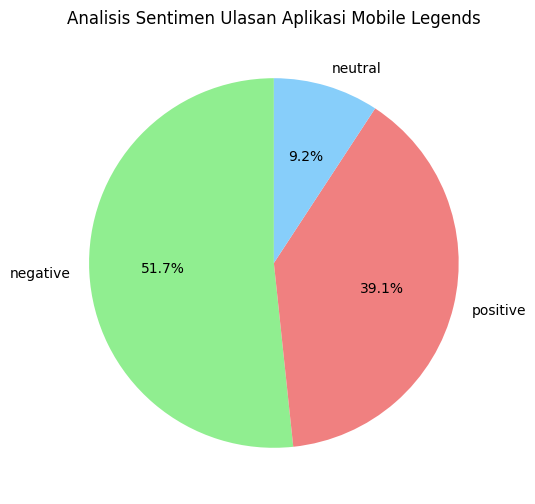

In [ ]:
sentiment_counts = clean_df['polarity'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral','lightskyblue'])
plt.title('Analisis Sentimen Ulasan Aplikasi Mobile Legends')
plt.show()

## **WorldCloud**

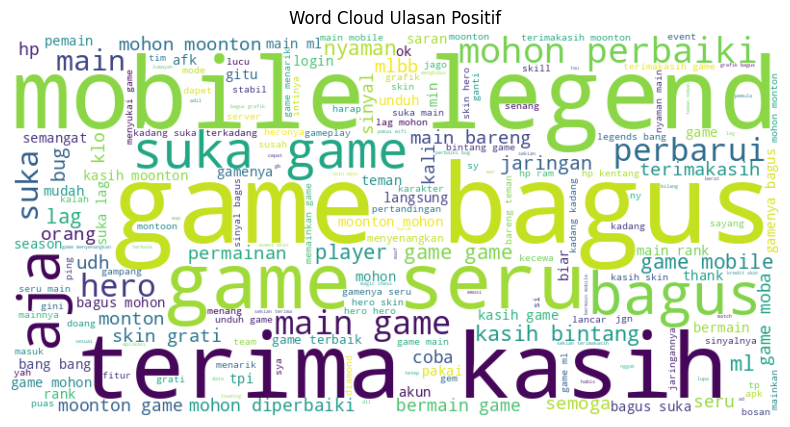

In [ ]:
# Filter data untuk ulasan positif
positive_reviews = clean_df[clean_df['polarity'] == 'positive']['text_akhir']

# Gabungkan semua teks ulasan positif
all_positive_text = ' '.join(positive_reviews)

# Buat objek WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(all_positive_text)

# Tampilkan word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Ulasan Positif')
plt.show()

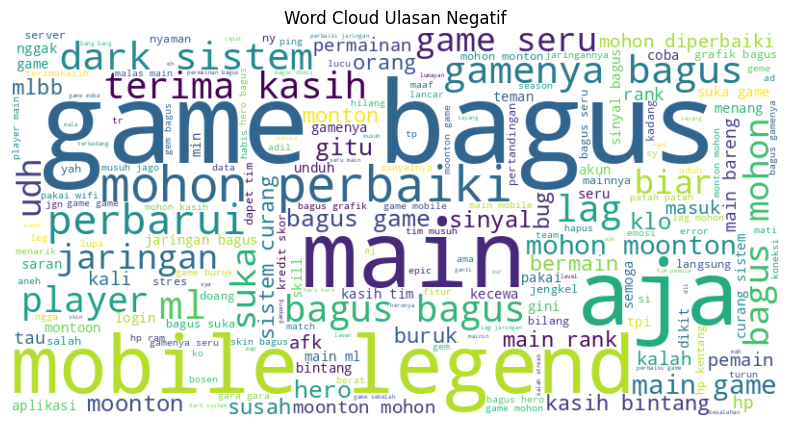

In [ ]:
# Filter data untuk ulasan negatif
negative_reviews = clean_df[clean_df['polarity'] == 'negative']['text_akhir']

# Gabungkan semua teks ulasan negatif
all_negative_text = ' '.join(negative_reviews)

# Buat objek WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(all_negative_text)

# Tampilkan word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Ulasan Negatif')
plt.show()

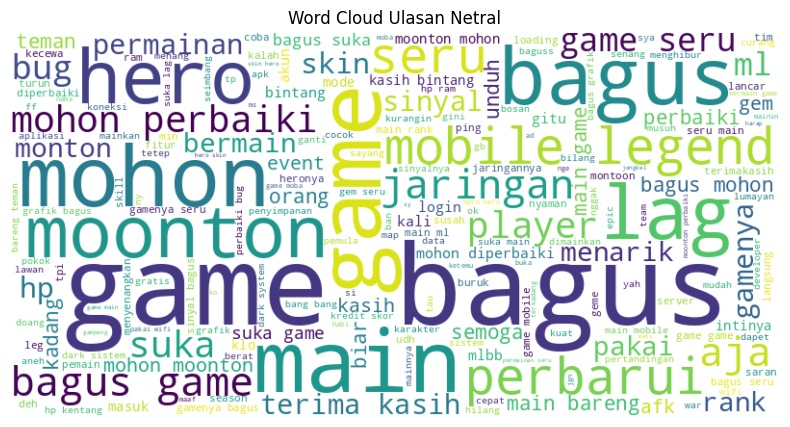

In [ ]:
# Filter data untuk ulasan negatif
negative_reviews = clean_df[clean_df['polarity'] == 'neutral']['text_akhir']

# Gabungkan semua teks ulasan negatif
all_negative_text = ' '.join(negative_reviews)

# Buat objek WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(all_negative_text)

# Tampilkan word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Ulasan Netral')
plt.show()

# **Eksport Dataset**

In [ ]:
df_export = clean_df[['text_akhir', 'score', 'polarity', 'at']]

df_export.to_csv('preprocessed_mobile_legends_reviews.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

!pipreqs "/content/drive/MyDrive/Colab Notebooks" --scan-notebooks

Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in /content/drive/MyDrive/Colab Notebooks/requirements.tx